Initial Dataset Shape: (367, 12)
KNN Accuracy with k=3: 35.14%
KNN Accuracy with k=5: 35.14%
KNN Accuracy with k=7: 39.19%


/tmp/ipykernel_847/1835422181.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_847/1835422181.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us


Best Optimal n_neighbors: 9
Optimized KNN Accuracy: 40.54%

Confusion Matrix:
 [[ 8  1 13]
 [ 5 10  9]
 [10  6 12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.36      0.36        22
           1       0.59      0.42      0.49        24
           2       0.35      0.43      0.39        28

    accuracy                           0.41        74
   macro avg       0.43      0.40      0.41        74
weighted avg       0.43      0.41      0.41        74



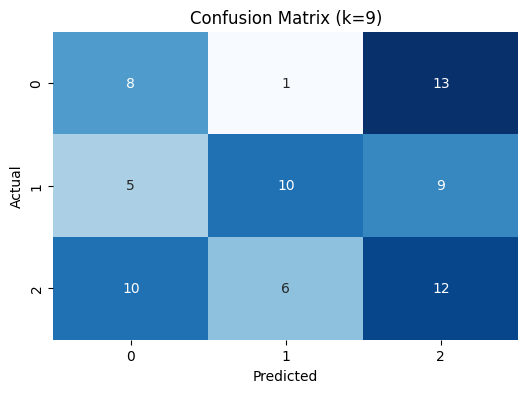

Model and Scaler saved successfully!


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the Dataset
df = pd.read_csv('loan.csv')
print("Initial Dataset Shape:", df.shape)

# Drop Loan_ID as it's a unique identifier, not a feature
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# 2. Handle Missing Values
# Fill numerical columns with median, categorical columns with mode
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Encode Categorical Variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Target variable (assuming 'Loan_Status' is the target)
target_col = 'Loan_Status' if 'Loan_Status' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Split Dataset into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Standardize Features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train KNN Model with Default Parameters & Experiment with k values
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(f"KNN Accuracy with k={k}: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 7. Hyperparameter Tuning using GridSearchCV for 'n_neighbors'
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"\nBest Optimal n_neighbors: {best_k}")

# Train final model with best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# 8. Model Evaluation & Metrics
y_pred_best = best_knn.predict(X_test_scaled)
print(f"Optimized KNN Accuracy: {accuracy_score(y_test, y_pred_best) * 100:.2f}%\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

# 9. Plot Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 10. Save Model and Scaler for Backend API
joblib.dump(best_knn, 'knn_loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and Scaler saved successfully!")